In [ ]:
# Installing necessary libraries
!pip install pandas
!pip install nltk
!pip install gensim
!pip install scikit-learn
!pip install matplotlib
!pip install vaderSentiment
!pip install transformers
!pip install pyLDAvis
!pip install spacy
!pip install flask
!pip install wordcloud

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.7/26.7 MB 39.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.6/38.6 MB 15.1 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.14.1
    Uninstalling scipy-1.14.1:
      Successfully uninstalled scipy-1.14.1
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 23.8 MB/s eta 0:00:00


In [ ]:
# Import required libraries
import pandas as pd
import nltk
import gensim
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis
import spacy
from gensim import corpora
from nltk.corpus import stopwords
from sklearn.decomposition import LatentDirichletAllocation
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from transformers import pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from gensim.models.coherencemodel import CoherenceModel
import matplotlib.pyplot as plt
from flask import Flask, request, jsonify
from gensim.models.coherencemodel import CoherenceModel
from wordcloud import WordCloud # Import the WordCloud class
import seaborn as sns
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from collections import Counter
import networkx as nx
from itertools import chain
from wordcloud import WordCloud
import nltk
from nltk.util import ngrams
from sklearn.feature_extraction.text import CountVectorizer # Import CountVectorizer
import seaborn as sns
import numpy as np
from google.colab import files

In [ ]:
# Download necessary NLTK & spaCy resources
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')
spacy.cli.download("en_core_web_sm")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
# Load the spaCy NLP model for Named Entity Recognition (NER)
nlp = spacy.load("en_core_web_sm")

In [ ]:
# 1️⃣ **Preprocessing with Lemmatization & NER**
def preprocess_text(text):
  text = text.lower()
  tokens = nltk.word_tokenize(text)
  stop_words = set(stopwords.words('english'))
  tokens = [word for word in tokens if word.isalpha() and word not in stop_words]

  # Lemmatization
  lemmatizer = nltk.WordNetLemmatizer()
  tokens = [lemmatizer.lemmatize(word) for word in tokens]

  return tokens

# Named Entity Recognition (NER) to extract brands, locations, and important names
def extract_entities(text):
  doc = nlp(text)
  return [ent.text for ent in doc.ents]

In [ ]:
# 2️⃣ **Load Dataset**
uploaded = files.upload()

# Load the CSV file (handling encoding issues)
try:
    df = pd.read_csv("review.csv", encoding="utf-8-sig")  # Try utf-8-sig first
except UnicodeDecodeError:
    df = pd.read_csv("review.csv", encoding="latin-1")  # Fallback to latin-1

# Printing actual column names
print("Column Names:", df.columns)
# Ensuring correct column name
df.rename(columns={df.columns[0]: "review"}, inplace=True)
# Converting 'review' column to a list
data = df["review"].tolist()
# Displaying first 5 reviews
print(data[:5])

# Preprocess text
preprocessed_data = [preprocess_text(review) for review in data]

# Extract Named Entities
entities = [extract_entities(review) for review in data]

# Create Dictionary and Corpus
dictionary = corpora.Dictionary(preprocessed_data)
corpus = [dictionary.doc2bow(text) for text in preprocessed_data]

Saving review.csv to review.csv
Column Names: Index(['review'], dtype='object')
['Love is complicated, but I wouldn’t want it any other way.', 'I just got a promotion! Let’s celebrate soon.', 'Did you watch the latest episode? It was insane!', 'Horrible service, waited over an hour for my meal.', 'Excellent sound quality, but the earbuds are a bit uncomfortable.']


In [ ]:
# 3️⃣ **Sentiment Analysis using BERT**
sentiment_analyzer = pipeline("sentiment-analysis")
def get_sentiment(text):
  sentiment = sentiment_analyzer(text)[0]
  return 1 if sentiment['label'] == 'POSITIVE' else -1
sentiments = [get_sentiment(review) for review in data]

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.
/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

Device set to use cpu


In [ ]:
# 4️⃣ **Find Optimal Number of Topics**
def find_optimal_topics(dictionary, corpus, texts, start=5, end=10):
  coherence_scores = []
  for num_topics in range(start, end):
    lda_model = gensim.models.LdaMulticore(
        corpus, num_topics=num_topics, id2word=dictionary, passes=10, workers=5
        )

    coherence_model = CoherenceModel(model=lda_model, texts=texts, dictionary=dictionary, coherence='c_v')
    coherence_scores.append((num_topics, coherence_model.get_coherence()))

  return sorted(coherence_scores, key=lambda x: x[1], reverse=True)[0]

best_num_topics, best_score = find_optimal_topics(dictionary, corpus, preprocessed_data)
print(f"Optimal Number of Topics: {best_num_topics}, Best Coherence Score: {best_score}")

Optimal Number of Topics: 5, Best Coherence Score: 0.4856854782404965


In [ ]:
# 5️⃣ **Train LDA Model with Optimized Topics**
lda = gensim.models.LdaMulticore(
    corpus, num_topics=best_num_topics, id2word=dictionary, passes=15, alpha='symmetric', eta='symmetric', workers=2
)

# Print Topics
print("\nLDA Topics:")
for idx, topic in lda.print_topics(-1):
  print(f"Topic {idx}: {topic}")


LDA Topics:
Topic 0: 0.029*"best" + 0.029*"ever" + 0.029*"care" + 0.029*"company" + 0.029*"avoid" + 0.029*"customer" + 0.022*"movie" + 0.022*"pasta" + 0.022*"restaurant" + 0.022*"episode"
Topic 1: 0.027*"need" + 0.027*"recommendation" + 0.027*"favorite" + 0.027*"book" + 0.021*"customer" + 0.021*"took" + 0.021*"frustrating" + 0.021*"support" + 0.021*"forever" + 0.021*"respond"
Topic 2: 0.037*"clean" + 0.037*"excellent" + 0.037*"service" + 0.037*"hotel" + 0.026*"let" + 0.026*"disappointing" + 0.026*"amazing" + 0.026*"fast" + 0.026*"life" + 0.026*"california"
Topic 3: 0.050*"feel" + 0.038*"go" + 0.032*"coffee" + 0.032*"bitter" + 0.032*"taste" + 0.032*"great" + 0.025*"best" + 0.025*"guilty" + 0.025*"let" + 0.025*"miss"
Topic 4: 0.037*"great" + 0.030*"experience" + 0.030*"staff" + 0.030*"polite" + 0.030*"helpful" + 0.030*"want" + 0.023*"know" + 0.023*"slide" + 0.023*"presentation" + 0.023*"meeting"


In [ ]:
# 6️⃣ **Hybrid Sentiment-Aware Filtering**
def sentiment_aware_topic_modeling(corpus, lda_model, sentiments):
  topic_scores = []
  for i, doc in enumerate(corpus):
    topic_distribution = lda_model[doc]
    sentiment = sentiments[i]
    adjusted_topics = [(topic, score * (1 + sentiment)) for topic, score in topic_distribution]
    topic_scores.append(adjusted_topics)
  return topic_scores

adjusted_topics = sentiment_aware_topic_modeling(corpus, lda, sentiments)
print("\nSentiment-Aware Adjusted Topics:")
for doc_topics in adjusted_topics:
  print(doc_topics)


Sentiment-Aware Adjusted Topics:
[(0, 0.0), (1, 0.0), (2, 0.0), (3, 0.0), (4, 0.0)]
[(0, 0.06667011231184006), (1, 0.06666996330022812), (2, 1.7325530052185059), (3, 0.06708109378814697), (4, 0.06702578812837601)]
[(0, 0.0), (1, 0.0), (2, 0.0), (3, 0.0), (4, 0.0)]
[(0, 0.0), (1, 0.0), (2, 0.0), (3, 0.0), (4, 0.0)]
[(0, 0.0), (1, 0.0), (2, 0.0), (3, 0.0), (4, 0.0)]
[(0, 0.0), (1, 0.0), (2, 0.0), (3, 0.0), (4, 0.0)]
[(0, 0.0), (1, 0.0), (2, 0.0), (3, 0.0), (4, 0.0)]
[(0, 0.0), (1, 0.0), (2, 0.0), (3, 0.0), (4, 0.0)]
[(0, 1.67927086353302), (1, 0.08021321147680283), (2, 0.080006442964077), (3, 0.08050531148910522), (4, 0.08000414073467255)]
[(0, 0.08006177097558975), (1, 0.08013350516557693), (2, 0.08050762861967087), (3, 1.6788065433502197), (4, 0.08049054443836212)]
[(0, 0.0), (1, 0.0), (2, 0.0), (3, 0.0), (4, 0.0)]
[(0, 0.0), (1, 0.0), (2, 0.0), (3, 0.0), (4, 0.0)]
[(0, 0.057380739599466324), (1, 1.7698274850845337), (2, 0.057151440531015396), (3, 0.058491915464401245), (4, 0.05714837

In [ ]:
# 7️⃣ **Evaluate LDA Model using Coherence & Perplexity**
perplexity = lda.log_perplexity(corpus)
print(f"\nModel Perplexity: {perplexity}")

coherence_model_lda = CoherenceModel(model=lda, texts=preprocessed_data, dictionary=dictionary, coherence='c_v')
coherence_score = coherence_model_lda.get_coherence()
print(f"Model Coherence Score: {coherence_score}")


Model Perplexity: -5.585328972141361
Model Coherence Score: 0.4972834421081244


In [ ]:
# 8️⃣ **Interactive Topic Visualization**
lda_display = gensimvis.prepare(lda, corpus, dictionary)
pyLDAvis.display(lda_display)

In [ ]:
# 9️⃣ **Save & Load Model**
lda.save("lda_model.model")
dictionary.save("lda_dictionary.dict")
corpora.MmCorpus.serialize("lda_corpus.mm", corpus)

# Load model later:
# lda = gensim.models.LdaMulticore.load("lda_model.model")

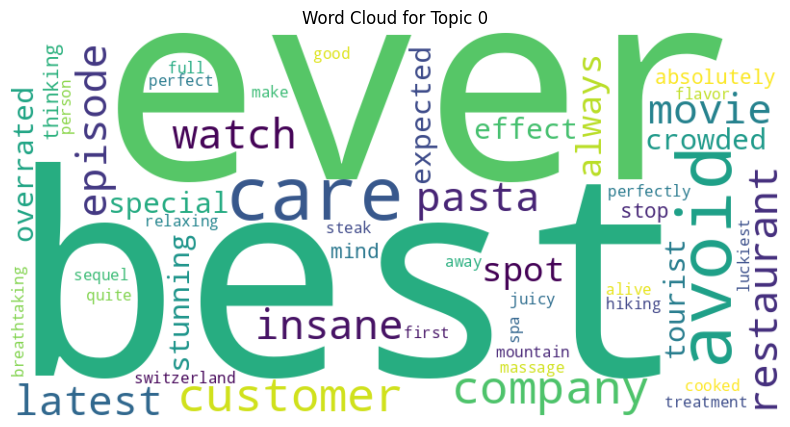

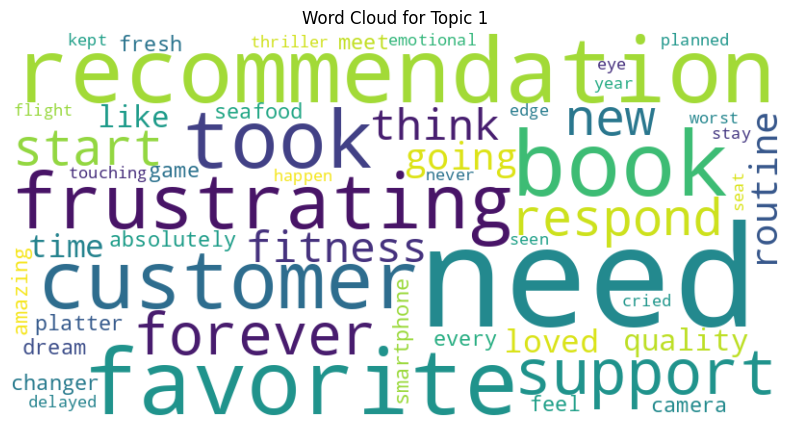

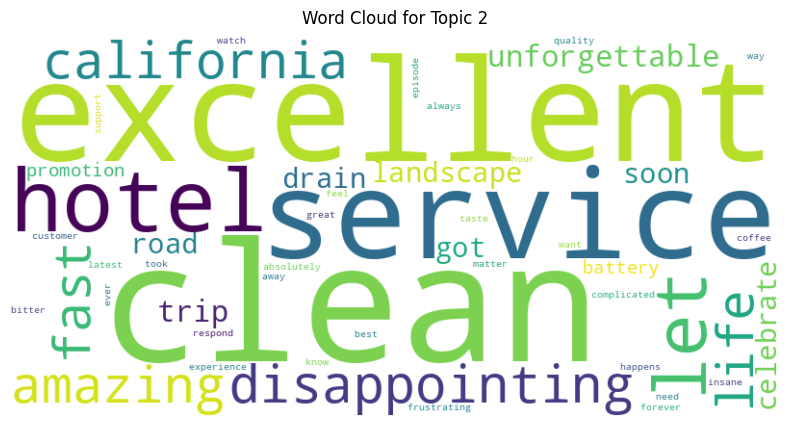

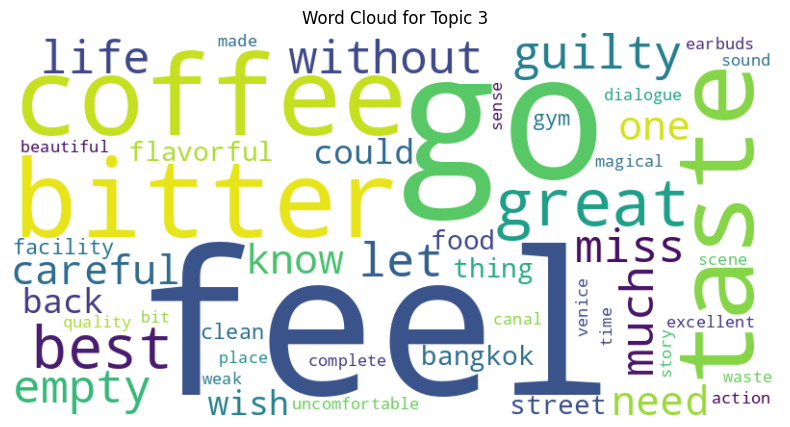

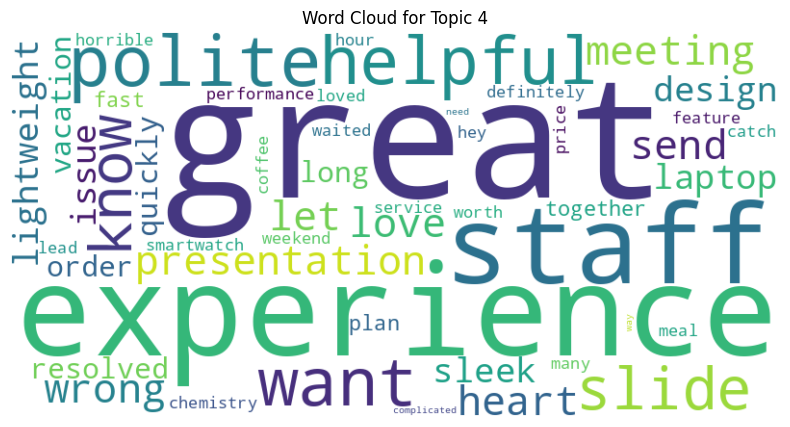

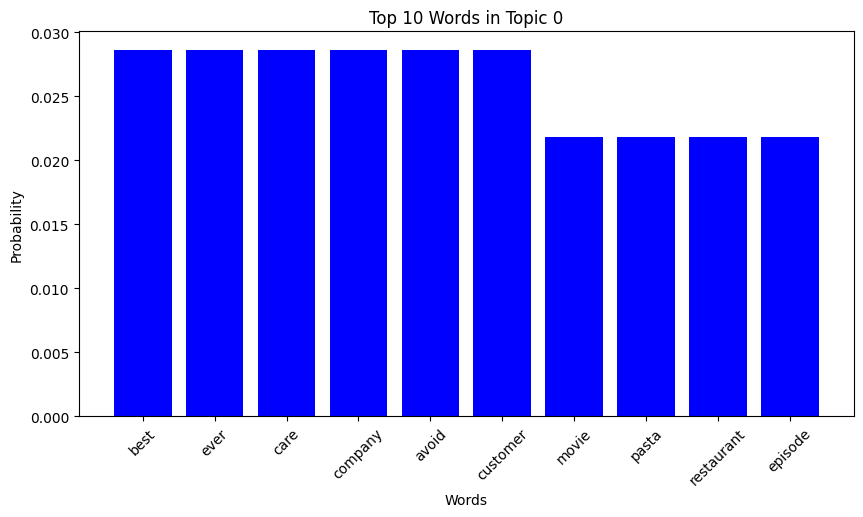

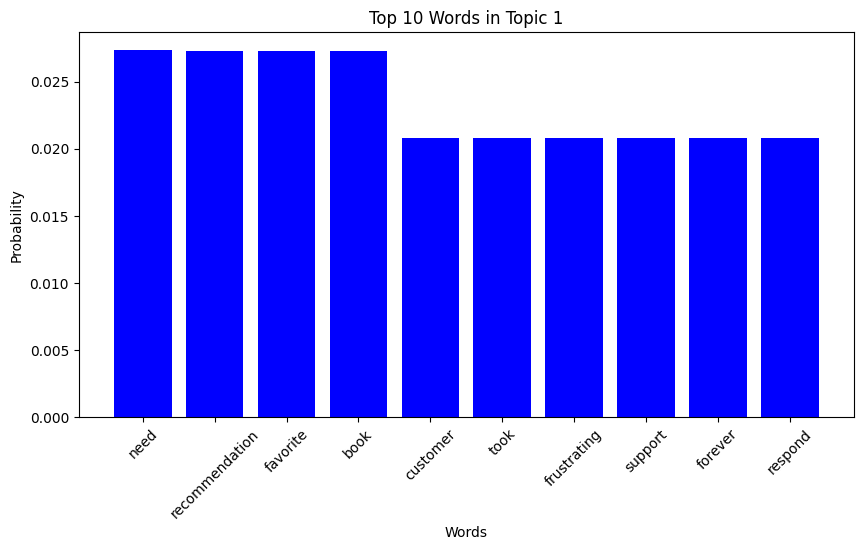

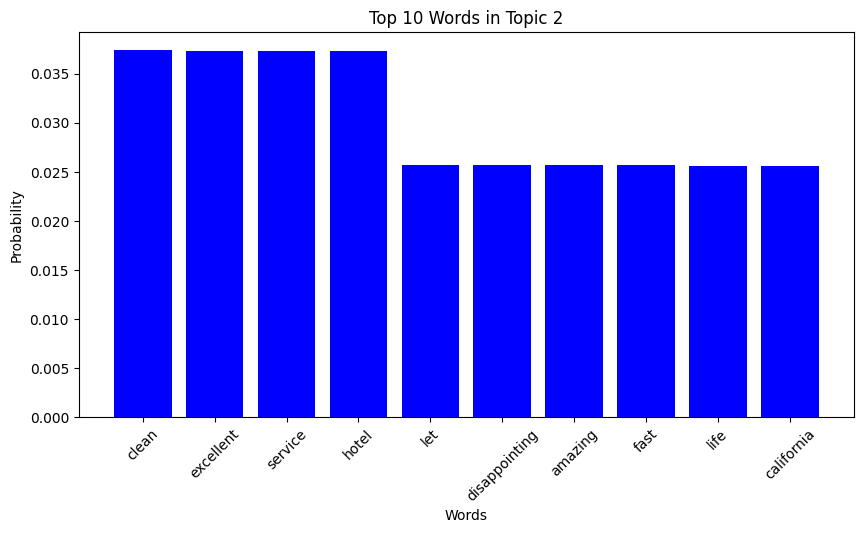

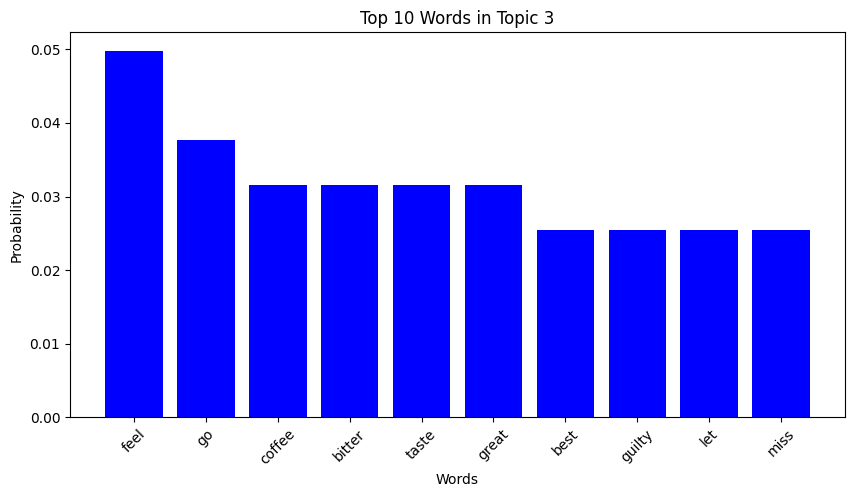

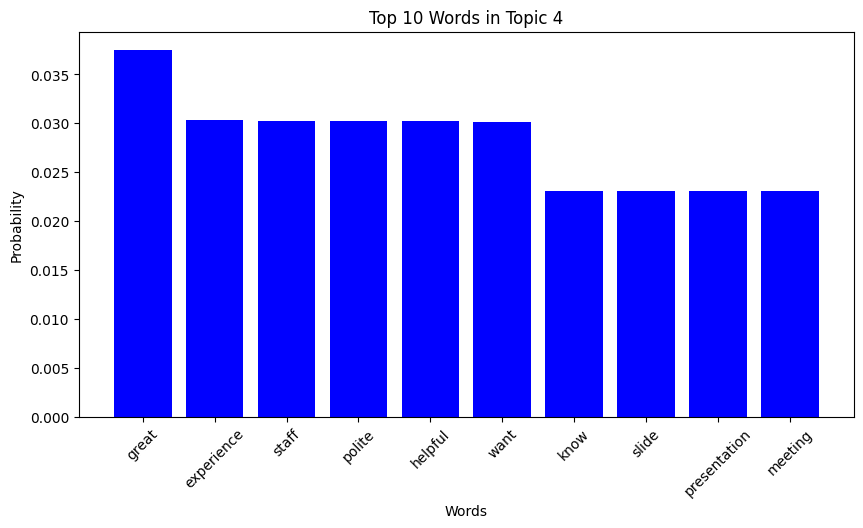

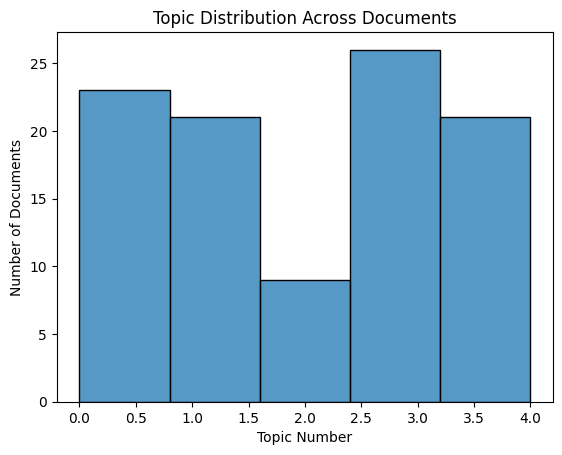

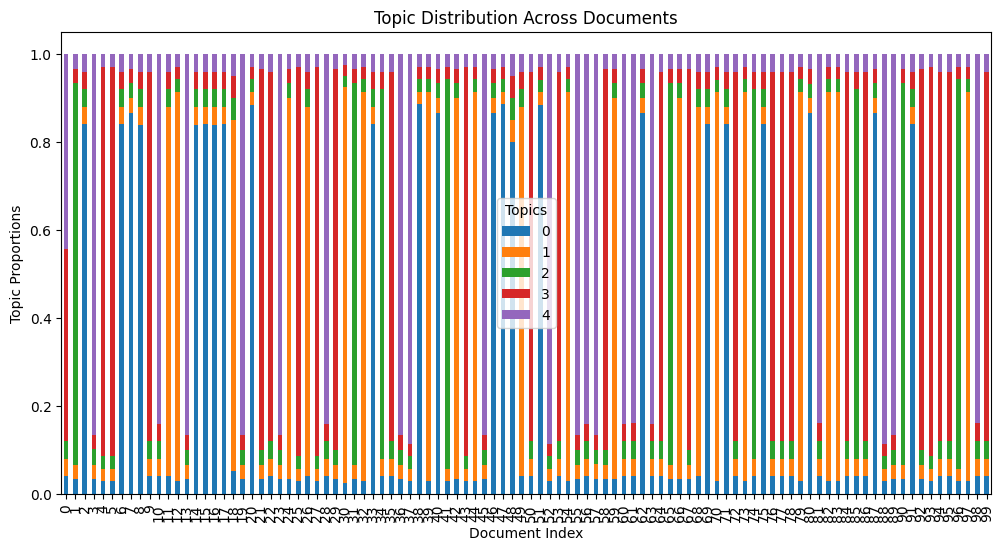

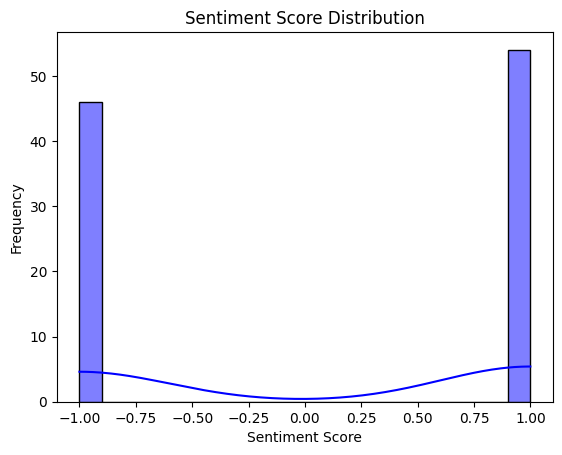

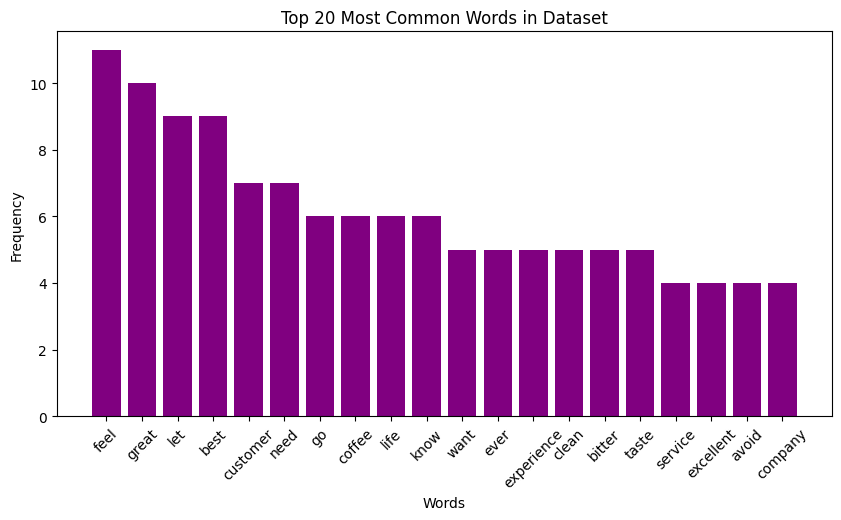

In [ ]:
# 1️⃣ **Word Cloud for Each Topic**
def plot_wordcloud_for_topics(lda_model, dictionary, num_topics):
  for i in range(num_topics):
    words = dict(lda_model.show_topic(i, 50)) # Get top 50 words
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(words)
    plt.figure(figsize=(10,5))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Word Cloud for Topic {i}")
    plt.show()
plot_wordcloud_for_topics(lda, dictionary, best_num_topics)

# 2️⃣ **Bar Plot for Top Words in Each Topic**
def plot_top_words_per_topic(lda_model, num_topics, num_words=10):
  for topic_id in range(num_topics):
    words = dict(lda_model.show_topic(topic_id, num_words))
    plt.figure(figsize=(10, 5))
    plt.bar(words.keys(), words.values(), color='blue')
    plt.xticks(rotation=45)
    plt.title(f"Top {num_words} Words in Topic {topic_id}")
    plt.xlabel("Words")
    plt.ylabel("Probability")
    plt.show()
plot_top_words_per_topic(lda, best_num_topics)

# 3️⃣ **Topic Distribution Across Documents (Stacked Bar Plot)**
## **Topic Distribution Per Document**
topic_assignments = [max(lda[doc], key=lambda x: x[1])[0] for doc in corpus]
sns.histplot(topic_assignments, bins=best_num_topics, kde=False)
plt.title("Topic Distribution Across Documents")
plt.xlabel("Topic Number")
plt.ylabel("Number of Documents")
plt.show()

def plot_topic_distribution_per_doc(corpus, lda_model):
  topic_distributions = [dict(lda_model[doc]) for doc in corpus]
  df = pd.DataFrame(topic_distributions).fillna(0)
  df.plot(kind='bar', stacked=True, figsize=(12,6))
  plt.title('Topic Distribution Across Documents')
  plt.xlabel('Document Index')
  plt.ylabel('Topic Proportions')
  plt.legend(title="Topics")
  plt.show()
plot_topic_distribution_per_doc(corpus, lda)

# 4️⃣ **Sentiment Score Distribution (Histogram + KDE)**
def plot_sentiment_distribution(sentiments):
  sns.histplot(sentiments, bins=20, kde=True, color='blue')
  plt.title("Sentiment Score Distribution")
  plt.xlabel("Sentiment Score")
  plt.ylabel("Frequency")
  plt.show()
plot_sentiment_distribution(sentiments)

# 5️⃣ **Most Common Words in Dataset (Bar Chart)**
def plot_most_common_words(preprocessed_data, num_words=20):
  word_counts = Counter([word for doc in preprocessed_data for word in doc])
  common_words = dict(word_counts.most_common(num_words))
  plt.figure(figsize=(10,5))
  plt.bar(common_words.keys(), common_words.values(), color='purple')
  plt.xticks(rotation=45)
  plt.title(f"Top {num_words} Most Common Words in Dataset")
  plt.xlabel("Words")
  plt.ylabel("Frequency")
  plt.show()
plot_most_common_words(preprocessed_data)

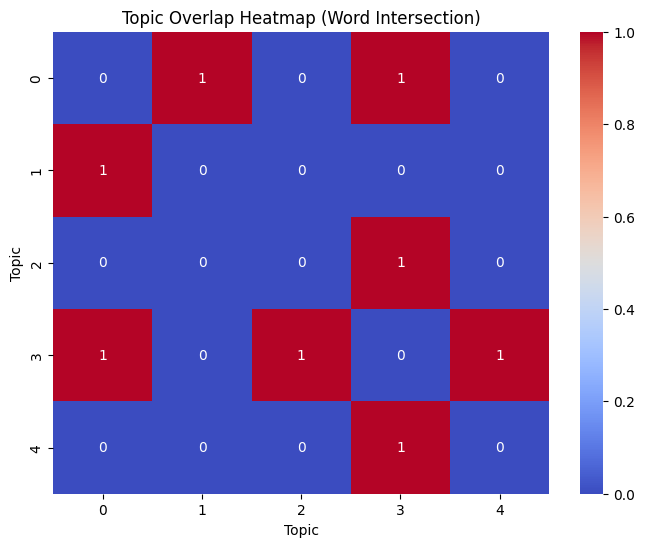

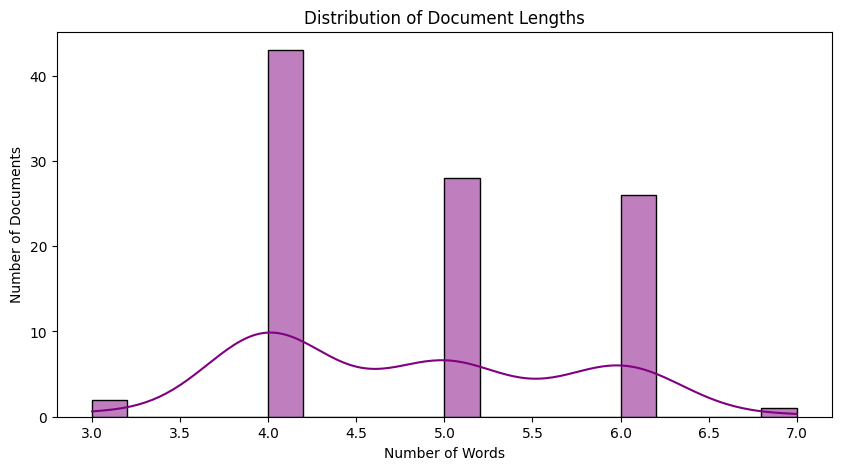

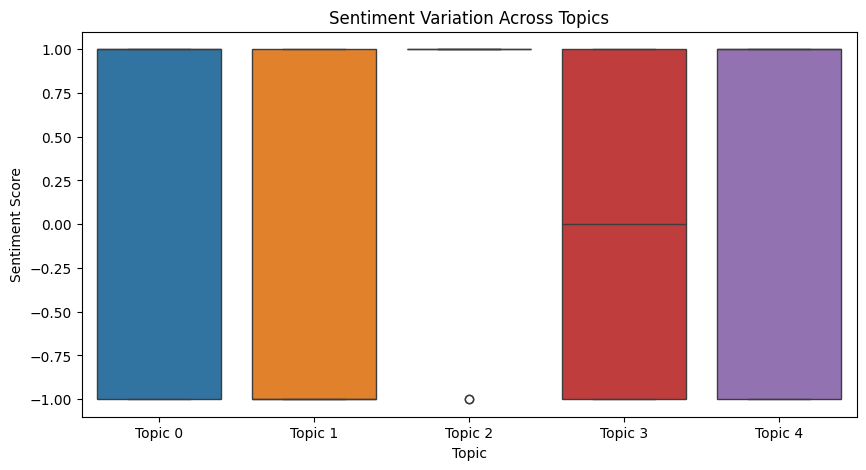

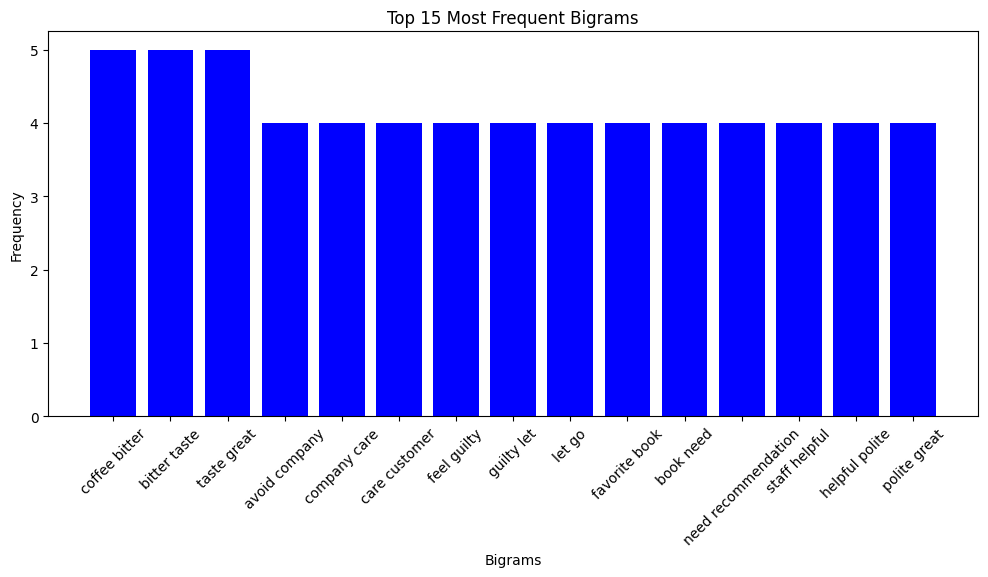

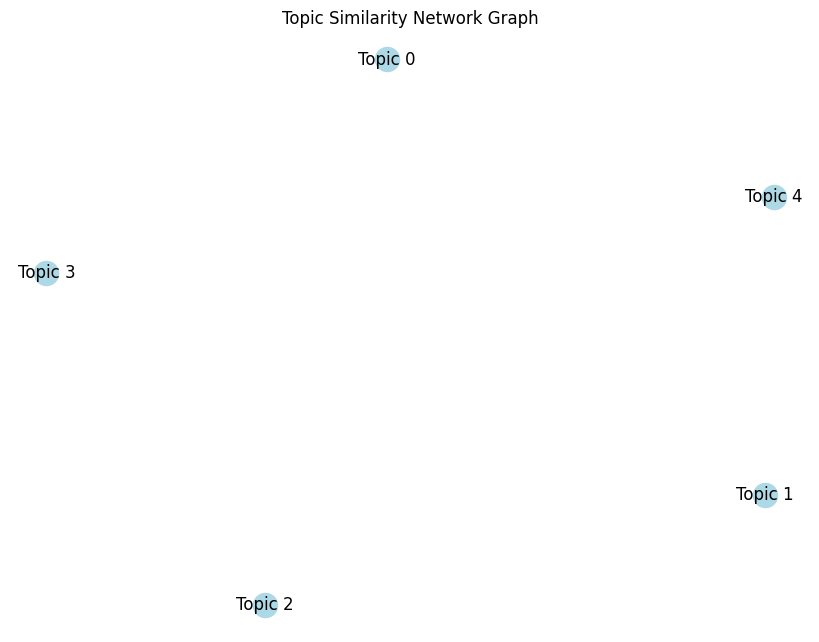

In [ ]:
# 1️⃣ **Topic Overlap Heatmap**
def plot_topic_overlap_heatmap(lda_model, num_topics):
    topic_words = [dict(lda_model.show_topic(i, 10)) for i in range(num_topics)]

    # Compute word overlap between topics
    overlap_matrix = np.zeros((num_topics, num_topics))
    for i in range(num_topics):
        for j in range(num_topics):
            if i != j:
                overlap_matrix[i, j] = len(set(topic_words[i].keys()) & set(topic_words[j].keys()))

    plt.figure(figsize=(8, 6))
    sns.heatmap(overlap_matrix, annot=True, cmap="coolwarm", fmt=".0f", xticklabels=range(num_topics), yticklabels=range(num_topics))
    plt.title("Topic Overlap Heatmap (Word Intersection)")
    plt.xlabel("Topic")
    plt.ylabel("Topic")
    plt.show()

plot_topic_overlap_heatmap(lda, best_num_topics)

# 2️⃣ **Document Length Distribution**
def plot_document_length_distribution(preprocessed_data):
    doc_lengths = [len(doc) for doc in preprocessed_data]

    plt.figure(figsize=(10, 5))
    sns.histplot(doc_lengths, bins=20, kde=True, color='purple')
    plt.title("Distribution of Document Lengths")
    plt.xlabel("Number of Words")
    plt.ylabel("Number of Documents")
    plt.show()

plot_document_length_distribution(preprocessed_data)

# 3️⃣ **Topic Sentiment Box Plot**
def plot_topic_sentiment_boxplot(corpus, lda_model, sentiments):
    topic_sentiments = {i: [] for i in range(best_num_topics)}

    for i, doc in enumerate(corpus):
        dominant_topic = max(lda_model[doc], key=lambda x: x[1])[0]
        topic_sentiments[dominant_topic].append(sentiments[i])

    plt.figure(figsize=(10, 5))
    sns.boxplot(data=[topic_sentiments[i] for i in range(best_num_topics)])
    plt.xticks(ticks=range(best_num_topics), labels=[f"Topic {i}" for i in range(best_num_topics)])
    plt.title("Sentiment Variation Across Topics")
    plt.xlabel("Topic")
    plt.ylabel("Sentiment Score")
    plt.show()

plot_topic_sentiment_boxplot(corpus, lda, sentiments)

# 4️⃣ **Bigram (Word Pair) Frequency Plot**
def plot_bigram_frequency(preprocessed_data, num_bigrams=15):
    bigram_list = list(chain.from_iterable([list(ngrams(doc, 2)) for doc in preprocessed_data]))
    bigram_counts = Counter(bigram_list)
    common_bigrams = bigram_counts.most_common(num_bigrams)

    plt.figure(figsize=(12, 5))
    plt.bar([" ".join(bigram) for bigram, _ in common_bigrams], [count for _, count in common_bigrams], color='blue')
    plt.xticks(rotation=45)
    plt.title(f"Top {num_bigrams} Most Frequent Bigrams")
    plt.xlabel("Bigrams")
    plt.ylabel("Frequency")
    plt.show()

plot_bigram_frequency(preprocessed_data)

# 5️⃣ **Topic Similarity Network Graph**
def plot_topic_similarity_network(lda_model, num_topics):
    G = nx.Graph()

    for i in range(num_topics):
        G.add_node(f"Topic {i}")

    for i in range(num_topics):
        for j in range(i + 1, num_topics):
            word_set_i = set(dict(lda_model.show_topic(i, 10)).keys())
            word_set_j = set(dict(lda_model.show_topic(j, 10)).keys())

            similarity = len(word_set_i & word_set_j) / len(word_set_i | word_set_j)
            if similarity > 0.2:  # Adjust similarity threshold
                G.add_edge(f"Topic {i}", f"Topic {j}", weight=similarity)

    plt.figure(figsize=(8, 6))
    pos = nx.spring_layout(G, seed=42)
    nx.draw(G, pos, with_labels=True, node_color='lightblue', edge_color='gray', width=[d["weight"] * 5 for (u, v, d) in G.edges(data=True)])
    plt.title("Topic Similarity Network Graph")
    plt.show()

plot_topic_similarity_network(lda, best_num_topics)


In [ ]:
# 3️⃣ **Create DTM (Document-Term Matrix)**
vectorizer = CountVectorizer()

# Join the tokenized words back into strings for each document
preprocessed_data_strings = [' '.join(tokens) for tokens in preprocessed_data]

dtm_matrix = vectorizer.fit_transform(preprocessed_data_strings) # Use the strings

# Convert to DataFrame for better visualization
dtm_df = pd.DataFrame(dtm_matrix.toarray(), columns=vectorizer.get_feature_names_out())
print("\nDocument-Term Matrix (DTM):")
print(dtm_df.head())

# 4️⃣ **Create TF-IDF Matrix**
tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(preprocessed_data_strings) # Use the strings

# Convert to DataFrame
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf_vectorizer.get_feature_names_out())
print("\nTF-IDF Matrix:")
print(tfidf_df.head())


Document-Term Matrix (DTM):
   absolutely  action  alive  always  amazing  avoid  away  back  bangkok  \
0           0       0      0       0        0      0     0     0        0   
1           0       0      0       0        0      0     0     0        0   
2           0       0      0       0        0      0     0     0        0   
3           0       0      0       0        0      0     0     0        0   
4           0       0      0       0        0      0     0     0        0   

   battery  ...  watch  way  weak  weekend  wish  without  worst  worth  \
0        0  ...      0    1     0        0     0        0      0      0   
1        0  ...      0    0     0        0     0        0      0      0   
2        0  ...      1    0     0        0     0        0      0      0   
3        0  ...      0    0     0        0     0        0      0      0   
4        0  ...      0    0     0        0     0        0      0      0   

   wrong  year  
0      0     0  
1      0     0  
2     

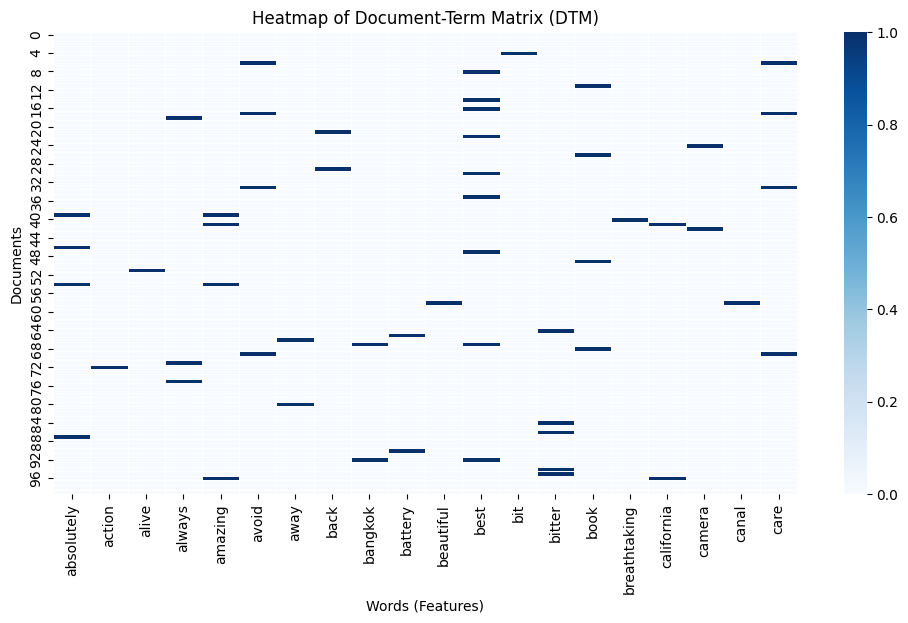

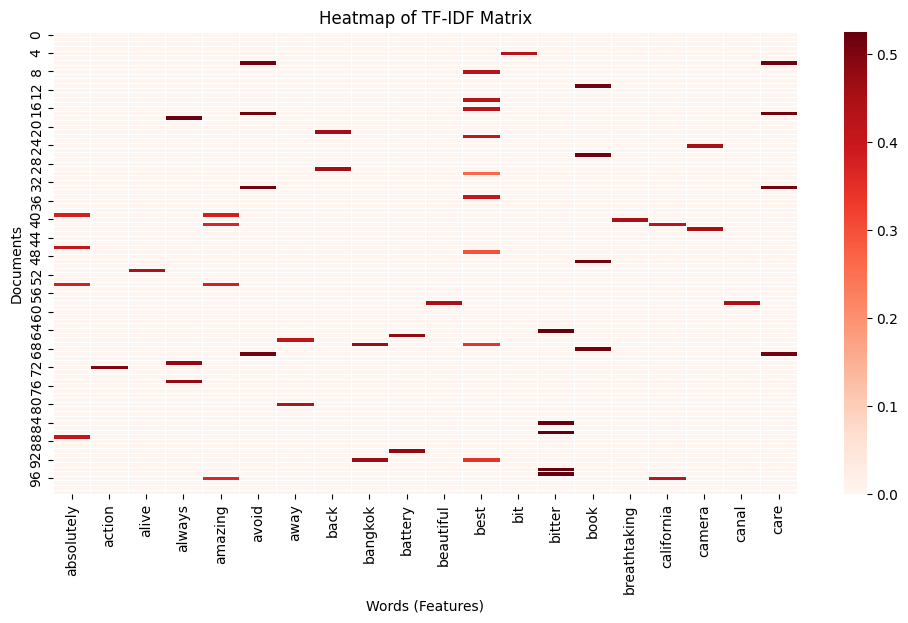

In [ ]:
# 1️⃣ **Plot Heatmap for DTM (Document-Term Matrix)**
def plot_dtm_heatmap(dtm_df):
  plt.figure(figsize=(12, 6))
  sns.heatmap(dtm_df.iloc[:, :20], cmap="Blues", annot=False, linewidths=0.5)
  plt.title("Heatmap of Document-Term Matrix (DTM)")
  plt.xlabel("Words (Features)")
  plt.ylabel("Documents")
  plt.show()
plot_dtm_heatmap(dtm_df)

# 2️⃣ **Plot Heatmap for TF-IDF Matrix**
def plot_tfidf_heatmap(tfidf_df):
  plt.figure(figsize=(12, 6))
  sns.heatmap(tfidf_df.iloc[:, :20], cmap="Reds", annot=False, linewidths=0.5)
  plt.title("Heatmap of TF-IDF Matrix")
  plt.xlabel("Words (Features)")
  plt.ylabel("Documents")
  plt.show()
plot_tfidf_heatmap(tfidf_df)